# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
% Note that this is a longer simulation of the model than we have used before.
% The longer simulation gives time to adapt SigmaV and SigmaW
load readonly/simOutLong.mat 

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the adaptive extended Kalman filter
The next notebook cells implement the initialization and iteration functions for the AEKF.

In [34]:
% AEKF initialization function, called once every simulation
function aekfData = initAEKF(xhat0,SigmaX0,priorU,model)
  aekfData.xhat   = xhat0;        % Initial state description  
  aekfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  aekfData.SigmaV = model.SigmaV; % Sensor-noise covariance 
  aekfData.SigmaW = model.SigmaW; % Process-noise covariance
  aekfData.priorU = priorU;       % Previous value of input force
  aekfData.model  = model; % Store model data structure too
  
  % For adaptive code: Storage of innovations and residues 
  NV = 500; #3000; %1000; % Length of buffer of past SigmaV to average
  aekfData.Vstore = zeros(1,NV);
  NW = 500; #3000; %1000; % Length of buffer of past SigmaW to average
  aekfData.Wstore = zeros(length(xhat0)^2,NW);
  
  aekfData.iter = 0; % The present iteration number "k"
end

In [35]:
% AEKF iteration function, called once every measurement interval
function [xhat,bounds,SigmaW,SigmaV,aekfData] = iterAEKF(uk,zk,dT,aekfData)
  model = aekfData.model;
  
  % Get data stored in ekfData structure
  priorU = aekfData.priorU;
  SigmaX = aekfData.SigmaX;
  SigmaV = aekfData.SigmaV;
  SigmaW = aekfData.SigmaW;
  xhat   = aekfData.xhat;
  
  % EKF Step 0: Compute Ahat[k-1]
  Ahat = [1 dT; -model.k1*dT/model.m-3*model.k2*dT*xhat(1)^2/model.m ...
          1-model.b*dT/model.m];
  
  % Step 1a: State estimate time update
  xhat = [1 dT; -model.k1*dT/model.m 1-model.b*dT/model.m]*xhat + ...
         [0; -model.k2*dT*xhat(1)^3/model.m] + [0; dT/model.m]*priorU;
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  % Note that Bhat is taken into account already in SigmaW by initEKF.m
  SigmaX = Ahat*SigmaX*Ahat' + SigmaW;
  
  % Step 1c: Output estimate
  zhat = atan(xhat(1)/model.d);
  
  % Step 2a: Estimator gain matrix
  Chat = [model.d/(model.d^2 + xhat(1)^2) 0]; Dhat = 1;
  SigmaZ = Chat*SigmaX*Chat' + Dhat*SigmaV*Dhat';
  L = SigmaX*Chat'/SigmaZ;
  
  % Step 2b: State estimate measurement update
  mu = zk - zhat; % innovation.  Use to check for sensor errors...
  xhat = xhat + L*mu;
  zhatplus = atan(xhat(1)/model.d);
  r = zk - zhatplus; % residue

  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % For adapting SigmaW
  alpha = 0.99; % simple filter pole location
  newW = (L*mu)*(L*mu)';
  aekfData.Wstore = [aekfData.Wstore(:,2:end), newW(:)]; % Buffer result
  if aekfData.iter > size(aekfData.Wstore,2) % Smooth with buffer AND filter
    newW = sum(aekfData.Wstore,2); % WARNING: Should be mean and not sum
    aekfData.SigmaW(:) = alpha*aekfData.SigmaW(:) + (1-alpha)*newW;
  end
  % For adapting SigmaV
  newV = r*r' + Chat*SigmaX*Chat';
  aekfData.Vstore = [aekfData.Vstore(2:end), newV(:)]; % Buffer result
  if aekfData.iter > size(aekfData.Vstore,2) % Smooth with buffer AND filter
    newV = mean(aekfData.Vstore,2);
    aekfData.SigmaV(:) = alpha*aekfData.SigmaV(:) + (1-alpha)*newV; 
  end
  
  % Save data in ekfData structure for next time...
  aekfData.priorU = uk;
  aekfData.SigmaX = SigmaX;
  aekfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));

  aekfData.iter = aekfData.iter + 1;
  SigmaW = aekfData.SigmaW(:);
  SigmaV = aekfData.SigmaV;
end

### Implementing the adaptive extended Kalman filter
The next notebook cells implement the main code of the adaptive extended Kalman filter.

In [36]:
% Determine number of states and timesteps
[nx,nt] = size(x); 

% Reserve storage for results
[nx,nt]    = size(x);
xhatstore  = zeros(nx,nt);
boundstore = zeros(nx,nt);
Qstore = zeros(nx^2,nt);
Rstore = zeros(1,nt);

% Covariance values
SigmaX0 = 0.1*eye(nx,nx); % uncertainty of initial state
xhat0   = zeros(nx,1);

% Create aekfData structure and initialize variables 
aekfData = initAEKF(xhat0,SigmaX0,u(1),model);

% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Compute estimate of present state vector and its bounds
  [xhatstore(:,k),boundstore(:,k),Qstore(:,k),Rstore(k),aekfData] = ...
    iterAEKF(uk,zk,dT,aekfData);
  if mod(aekfData.iter,10000) == 0
    fprintf('Simulated %d out of %d iterations\n',aekfData.iter,nt);
  end
end

Simulated 10000 out of 200001 iterations
Simulated 20000 out of 200001 iterations
Simulated 30000 out of 200001 iterations
Simulated 40000 out of 200001 iterations
Simulated 50000 out of 200001 iterations
Simulated 60000 out of 200001 iterations
Simulated 70000 out of 200001 iterations
Simulated 80000 out of 200001 iterations
Simulated 90000 out of 200001 iterations
Simulated 100000 out of 200001 iterations
Simulated 110000 out of 200001 iterations
Simulated 120000 out of 200001 iterations
Simulated 130000 out of 200001 iterations
Simulated 140000 out of 200001 iterations
Simulated 150000 out of 200001 iterations
Simulated 160000 out of 200001 iterations
Simulated 170000 out of 200001 iterations
Simulated 180000 out of 200001 iterations
Simulated 190000 out of 200001 iterations
Simulated 200000 out of 200001 iterations


### Plot simulation outputs from the adaptive extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

In [37]:
% Isolate the final 1000 samples for plotting
tseg = t(end-1000:end); tseg = tseg - tseg(1);
xseg = x(:,end-1000:end);
xhatseg = xhatstore(:,end-1000:end);
boundseg = boundstore(:,end-1000:end);
errseg = xseg - xhatseg;

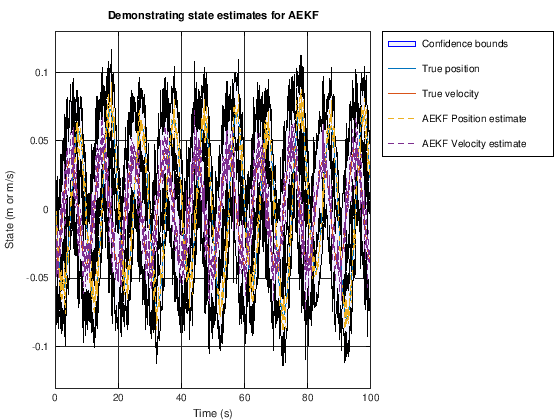

In [38]:
% Plot the states with confidence bounds
t2 = [tseg fliplr(tseg)]; % Prepare for plotting bounds via "fill"
x2 = [xhatseg-boundseg fliplr(xhatseg+boundseg)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(tseg,xseg',tseg,xhatseg','--'); ylim([-0.13 0.13]);
legend([h2;h1a],{'True position','True velocity','AEKF Position estimate',...
  'AEKF Velocity estimate','Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for AEKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

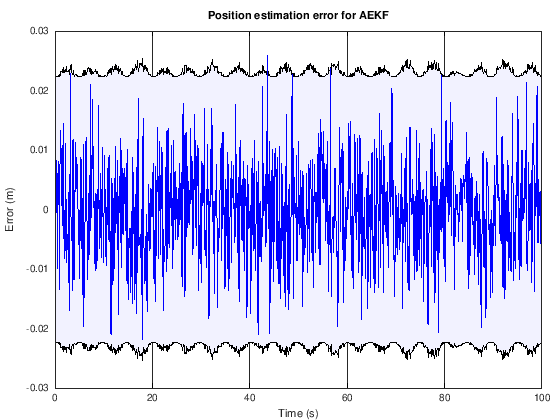

In [39]:
fill([tseg fliplr(tseg)],[-boundseg(1,:) fliplr(boundseg(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(tseg,errseg(1,:),'b');
title('Position estimation error for AEKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

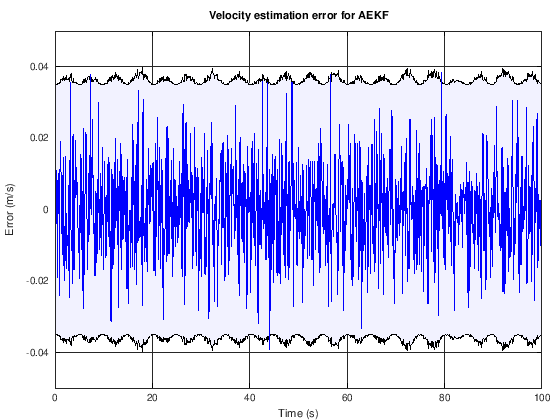

In [40]:
fill([tseg fliplr(tseg)],[-boundseg(2,:) fliplr(boundseg(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(tseg,errseg(2,:),'b'); ylim([-0.05 0.05]);
title('Velocity estimation error for AEKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

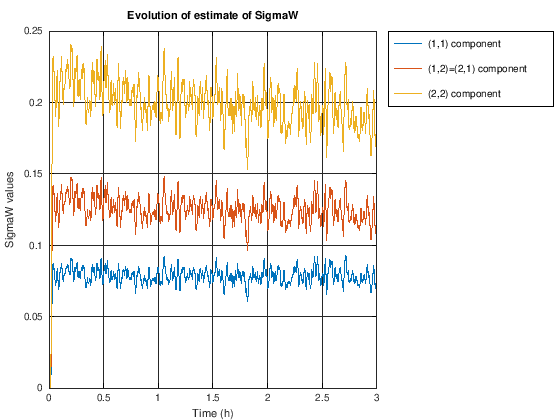

In [41]:
% I plot every tenth point for speed
h1 = plot(t(1:10:end)/3600,Qstore(1,1:10:end)); title('Evolution of estimate of SigmaW'); grid on
xlabel('Time (h)'); 
ylabel('SigmaW values'); hold on
h2 = plot(t(1:10:end)/3600,Qstore(3:4,1:10:end)); 
xlim([0 3]); 
legend([h1;h2],{'(1,1) component','(1,2)=(2,1) component','(2,2) component'},'location','bestOutside');

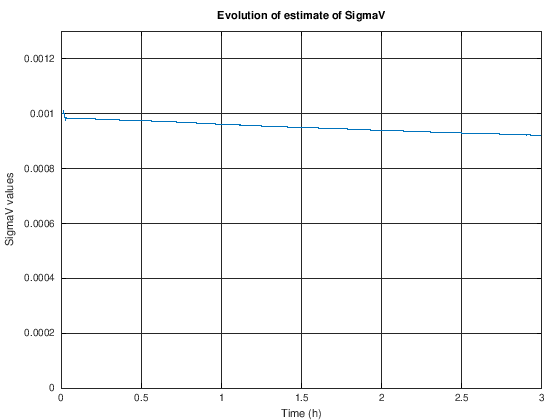

In [42]:
h1=plot(t(1:10:end)/3600,Rstore(1:10:end)); title('Evolution of estimate of SigmaV'); grid on
xlabel('Time (h)'); ylabel('SigmaV values')
ylim([0 1.3e-3]); xlim([0 3]); 

In [43]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(errseg(:)));
# 0.00969069
ind = find(abs(errseg(:))>boundseg(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundseg(:))*100);
# 0.14985%

RMS state estimation error = 0.0107847
Time error outside bounds = 0.2997%


In [44]:
model

model =

  scalar structure containing the fields:

    k1 =  4
    k2 =  60
    b =  2
    m =  50
    d =  0.25000
    SigmaW =

       1.3291e-09   1.9915e-08
       1.9915e-08   3.9830e-07

    Sw =  0.010000
    SigmaV =  0.0010000



In [45]:
Qstore(1,end)
Qstore(3:4,end)

ans =  0.076360
ans =

   0.11482
   0.17266



In [46]:
Rstore(end)

ans =    8.8309e-04
